In [112]:
#Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [113]:
# Load dataset
df = pd.read_csv("weather_classification_data.csv")
df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


### *Data Inspection*

In [114]:
df.shape # Shape of the data

(13200, 11)

In [115]:
print(df.info())        # shows column names, data types, missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  object 
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  object 
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  object 
 10  Weather Type          13200 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1.1+ MB
None


In [116]:
df.describe() #Summary of data

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km)
count,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000
mean,19.127576,68.710833,9.832197,53.644394,1005.827896,4.005758,5.462917
std,17.386327,20.194248,6.908704,31.946541,37.199589,3.856600,3.371499
min,-25.000000,20.000000,0.000000,0.000000,800.120000,0.000000,0.000000
25%,4.000000,57.000000,5.000000,19.000000,994.800000,1.000000,3.000000
50%,21.000000,70.000000,9.000000,58.000000,1007.650000,3.000000,5.000000
75%,31.000000,84.000000,13.500000,82.000000,1016.772500,7.000000,7.500000
max,109.000000,109.000000,48.500000,109.000000,1199.210000,14.000000,20.000000


In [117]:
print(df['Weather Type'].value_counts())  # check class distribution

Rainy     3300
Cloudy    3300
Sunny     3300
Snowy     3300
Name: Weather Type, dtype: int64


In [118]:
df.isnull().sum() #Checking for null values

Temperature             0
Humidity                0
Wind Speed              0
Precipitation (%)       0
Cloud Cover             0
Atmospheric Pressure    0
UV Index                0
Season                  0
Visibility (km)         0
Location                0
Weather Type            0
dtype: int64

In [119]:
df.duplicated().sum() #Duplicate values

0

### *Data Cleaning*

In [120]:
# Standardize column names: lowercase + replace spaces with underscores

df.columns = (df.columns.str.strip()
              .str.lower()
              .str.replace(" ", "_")
              .str.replace(r"[\[\] (\)]", "", regex=True)   # remove brackets/parentheses
              .str.replace(r"[^a-z0-9_]", "", regex=True)  # remove other special chars
)

In [121]:
df = df.rename(columns={"precipitation_": "precipitation"}) #Renaming precipitation column to remove the underscore

In [122]:
# Standardizing values in categorical columns

# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Convert all categorical values to lowercase
for col in categorical_cols:
    df[col] = df[col].str.strip().str.lower()

In [123]:
df.head()

,temperature,humidity,wind_speed,precipitation,cloud_cover,atmospheric_pressure,uv_index,season,visibility_km,location,weather_type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,winter,3.5,inland,rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,spring,10.0,inland,cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,spring,5.5,mountain,sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,spring,1.0,coastal,sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,winter,2.5,mountain,rainy


### *EDA*

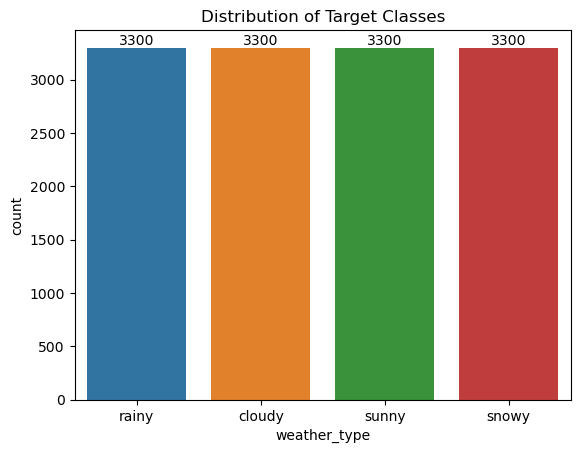

In [124]:
# What is the distribution of the target classes?

# Target distribution
ax = sns.countplot(x='weather_type', data=df)
for container in ax.containers:
    ax.bar_label(container)
plt.title("Distribution of Target Classes")
plt.show()

In [125]:
#How many unique values exist in each categorical column?

for col in df.select_dtypes(include=['object']).columns:
    print(f"{col}: {df[col].nunique()} unique values")

cloud_cover: 4 unique values
season: 4 unique values
location: 3 unique values
weather_type: 4 unique values


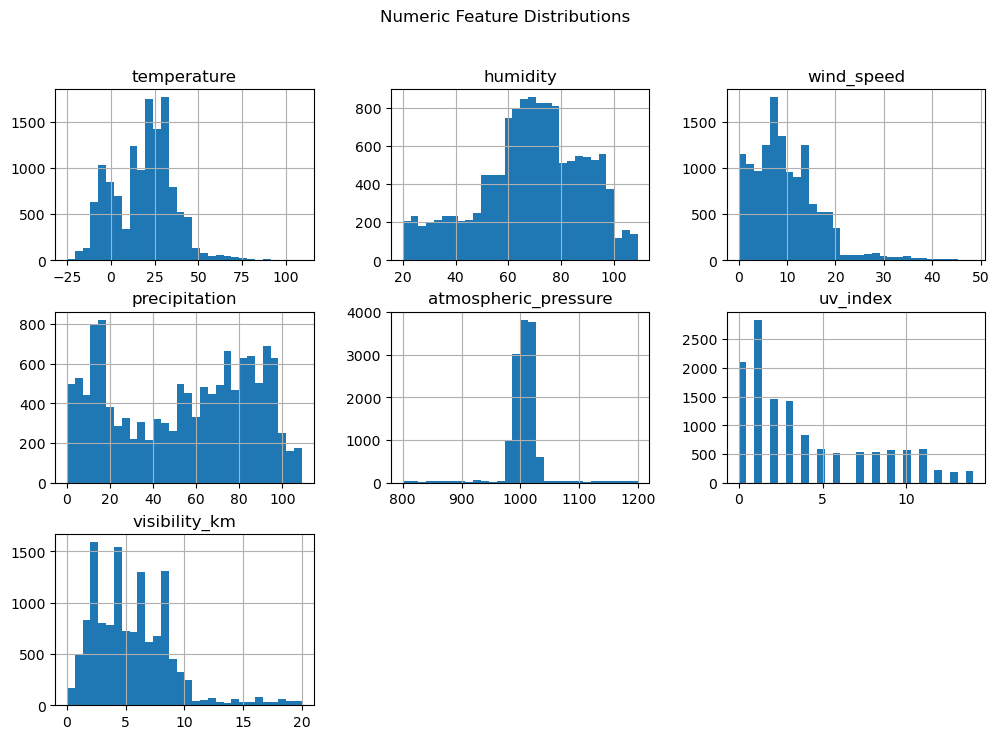

In [126]:
#What are the distributions of numeric features?

numeric_cols = ['temperature', 'humidity', 'wind_speed', 'precipitation', 'atmospheric_pressure', 'uv_index', 'visibility_km']
df[numeric_cols].hist(bins=30, figsize=(12,8))
plt.suptitle("Numeric Feature Distributions")
plt.show()

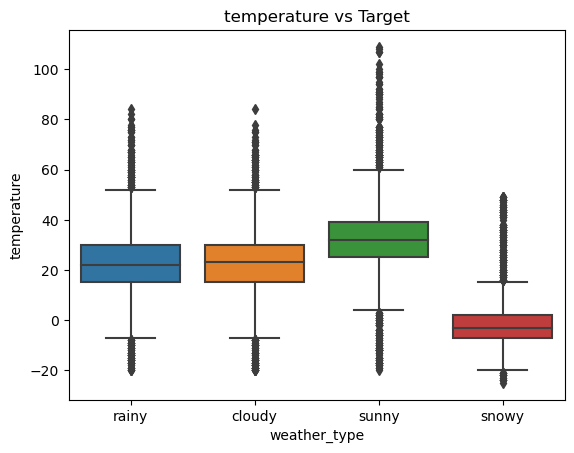

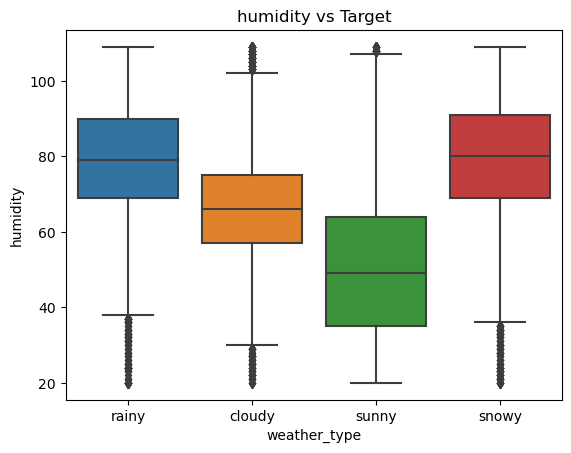

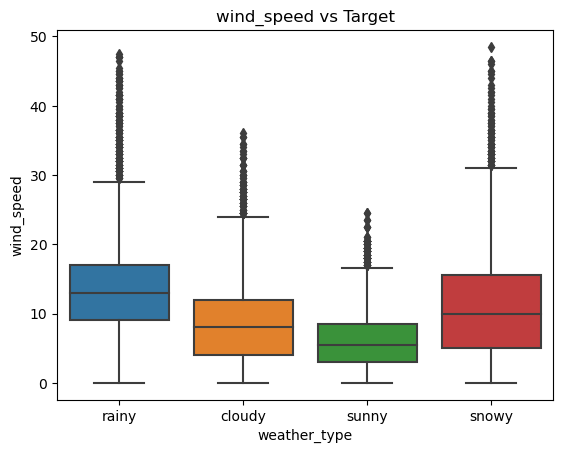

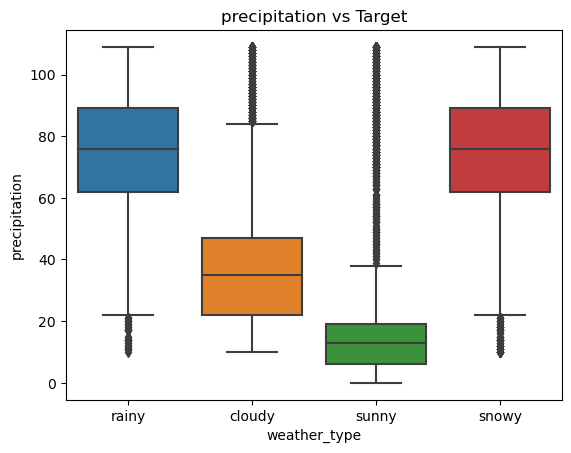

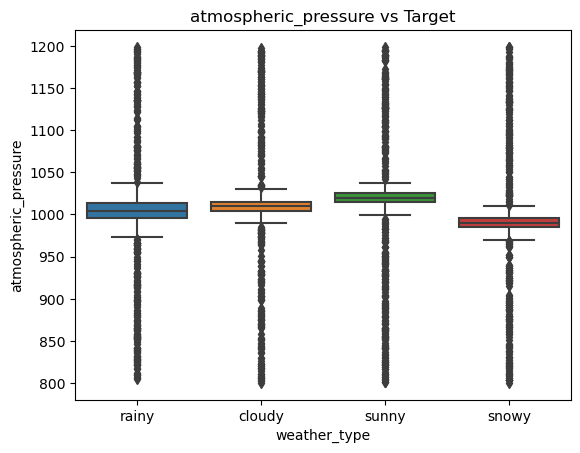

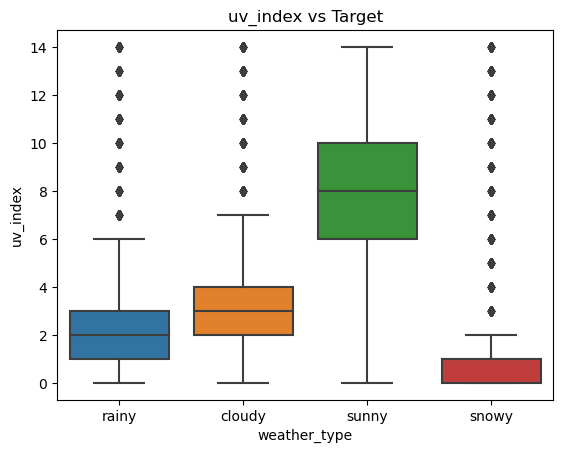

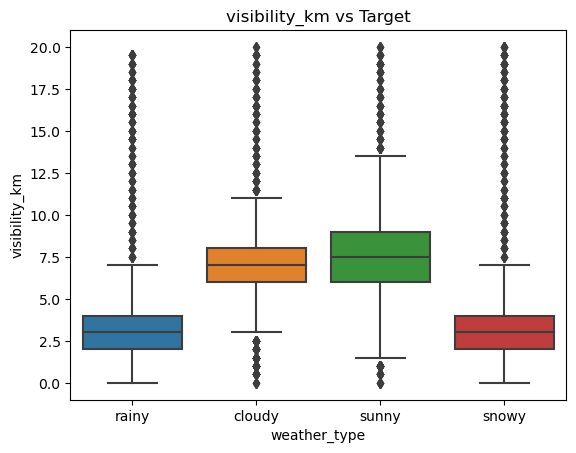

In [127]:
#How does numeric feature vary across target variable?

for col in numeric_cols:
    sns.boxplot(x='weather_type', y=col, data=df)
    plt.title(f"{col} vs Target")
    plt.show()

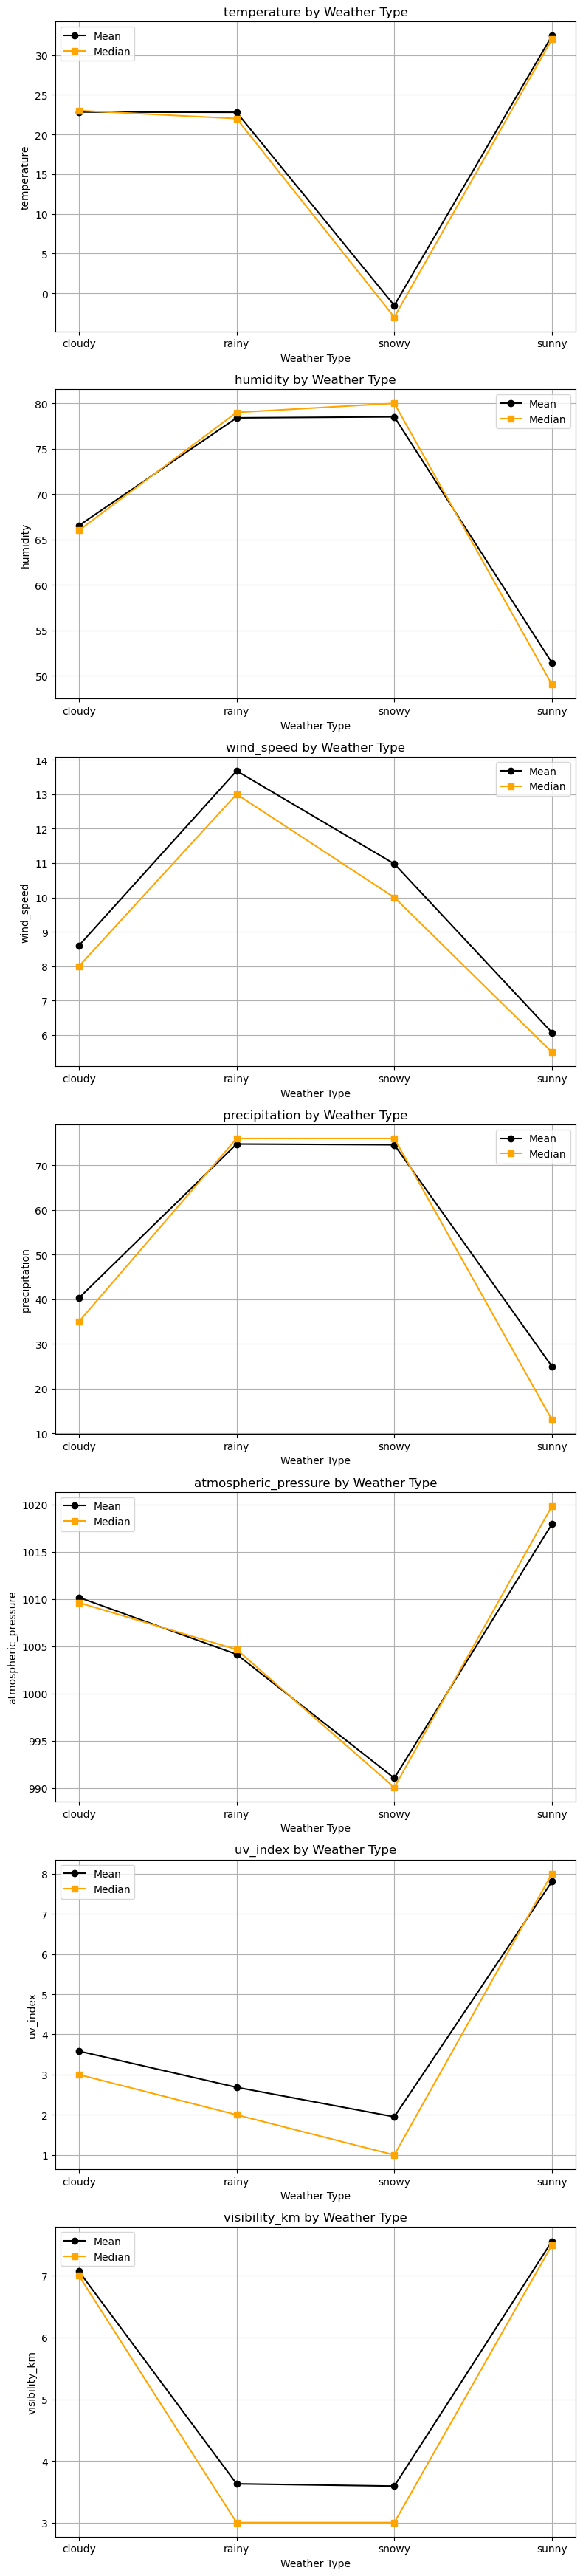

In [128]:
#How do the mean and median values of each numeric feature vary across different weather types?

# Group by target and compute mean & median for each numeric column
stats = df.groupby('weather_type')[numeric_cols].agg(['mean','median'])

# Create subplots: one per numeric column
fig, axes = plt.subplots(nrows=len(numeric_cols), ncols=1, figsize=(8, 5*len(numeric_cols)))

# If only one numeric column, axes is not iterable
if len(numeric_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, numeric_cols):
    # Extract mean and median for this column
    mean_vals = stats[col]['mean']
    median_vals = stats[col]['median']
    
    # Plot mean and median lines
    ax.plot(mean_vals.index, mean_vals.values, marker='o', color='black', label='Mean')
    ax.plot(median_vals.index, median_vals.values, marker='s', color='orange', label='Median')
    
    # Add labels and title
    ax.set_title(f"{col} by Weather Type")
    ax.set_xlabel("Weather Type")
    ax.set_ylabel(col)
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

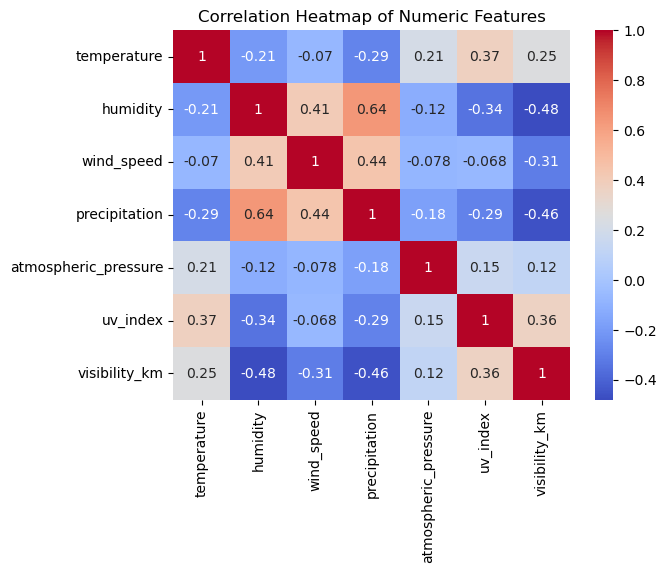

In [129]:
#Are numeric features correlated with each other?

corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


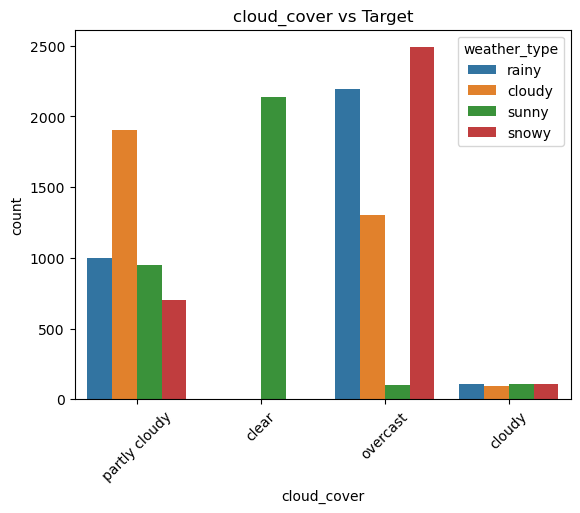

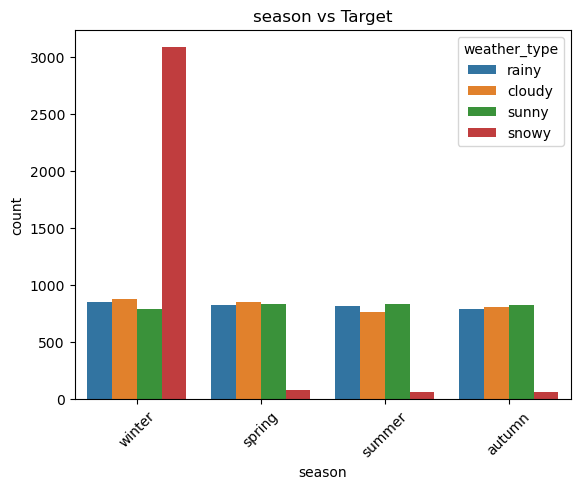

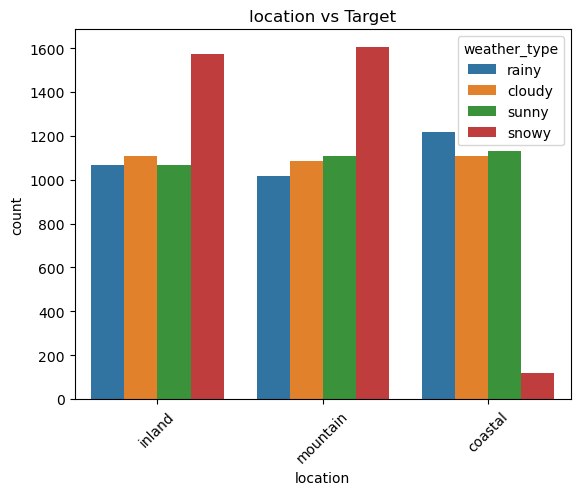

In [130]:
#Are categorical features correlated with target?
for col in categorical_cols:
    if col != 'weather_type':
        sns.countplot(x=col, hue='weather_type', data=df)
        plt.title(f"{col} vs Target")
        plt.xticks(rotation=45)
        plt.show()

In [131]:
#Are there any outliers in numerical columns?
from scipy import stats

for col in numeric_cols:
    z_scores = stats.zscore(df[col])
    outliers = (abs(z_scores) > 3).sum()
    print(f"{col}: {outliers} outliers")


temperature: 92 outliers
humidity: 0 outliers
wind_speed: 236 outliers
precipitation: 0 outliers
atmospheric_pressure: 556 outliers
uv_index: 0 outliers
visibility_km: 282 outliers


### *Data Preprocessing*

In [132]:
#Handling outliers

def cap_outliers(df, numeric_cols):
    """
    Caps outliers in numeric columns using the IQR method.
    Values below Q1 - 1.5*IQR are set to the lower cap,
    values above Q3 + 1.5*IQR are set to the upper cap.
    """
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_cap = Q1 - 1.5 * IQR
        upper_cap = Q3 + 1.5 * IQR
        
        df[col] = np.where(df[col] < lower_cap, lower_cap,
                           np.where(df[col] > upper_cap, upper_cap, df[col]))
    return df

# Apply to numeric columns
df = cap_outliers(df, numeric_cols)

In [133]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Identify feature types
numeric_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.drop('weather_type').tolist()

# Preprocessor for non-tree models (scale + one-hot)
preprocessor_scaled = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])

# Preprocessor for tree-based models (no scaling, only one-hot)
preprocessor_unscaled = ColumnTransformer([
    ("num", "passthrough", numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])


In [134]:
# Feature selection

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
X = df.drop('weather_type', axis=1)
y = label_encoder.fit_transform(df['weather_type'])

In [135]:
from sklearn.model_selection import train_test_split
# Splitting into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### *Modeling*

In [136]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [137]:
# Model Definition

models = {
    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor_scaled),
        ("classifier", LogisticRegression(max_iter=1000))
    ]),
    "KNN": Pipeline([
        ("preprocessor", preprocessor_scaled),
        ("classifier", KNeighborsClassifier())
    ]),
    "SVM": Pipeline([
        ("preprocessor", preprocessor_scaled),
        ("classifier", SVC())
    ]),
    "Decision Tree": Pipeline([
        ("preprocessor", preprocessor_unscaled),
        ("classifier", DecisionTreeClassifier())
    ]),
    "Random Forest": Pipeline([
        ("preprocessor", preprocessor_unscaled),
        ("classifier", RandomForestClassifier())
    ]),
    "XGBoost": Pipeline([
        ("preprocessor", preprocessor_unscaled),
        ("classifier", XGBClassifier(use_label_encoder=False, eval_metric="mlogloss"))
    ])
}

In [138]:
#Hyperparameter Tuning for different models

param_grids = {
    "Logistic Regression": {"classifier__C":[0.1,1,10]},
    "KNN": {"classifier__n_neighbors":[3,5,7,9]},
    "SVM": {"classifier__C":[0.1,1,10], "classifier__kernel":["linear","rbf"]},
    "Decision Tree": {"classifier__max_depth":[None,5,10], "classifier__min_samples_split":[2,5]},
    "Random Forest": {"classifier__n_estimators":[100,200], "classifier__max_depth":[None,10,20]},
    "XGBoost": {"classifier__n_estimators":[100,200], "classifier__max_depth":[3,5,7],
                "classifier__learning_rate":[0.01,0.1,0.2], "classifier__subsample":[0.8,1.0]}
}


In [139]:
# Cross validation

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report

cv = StratifiedKFold(n_splits= 5, shuffle= True, random_state= 42)

results = {} #For storing the results of models
best_models = {} #For storing the best model

In [140]:
# Model training and ealuation
for name, pipeline in models.items():
    grid = GridSearchCV(pipeline, param_grids[name], cv=cv, scoring="accuracy", n_jobs=-1)
    grid.fit(X_train, y_train)   # raw X_train, pipeline handles preprocessing
    
    best_models[name] = grid.best_estimator_
    y_pred = grid.best_estimator_.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")
    
    results[name] = {"accuracy": acc, "f1": f1, "best_params": grid.best_params_}
    
    print(f"\n{name}")
    print("Best Params:", grid.best_params_)
    print("Test Accuracy:", acc)
    print("Test F1 Score:", f1)
    print(classification_report(y_test, y_pred))


Logistic Regression
Best Params: {'classifier__C': 10}
Test Accuracy: 0.8715909090909091
Test F1 Score: 0.8718549277135351
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       660
           1       0.86      0.86      0.86       660
           2       0.89      0.92      0.90       660
           3       0.93      0.86      0.89       660

    accuracy                           0.87      2640
   macro avg       0.87      0.87      0.87      2640
weighted avg       0.87      0.87      0.87      2640


KNN
Best Params: {'classifier__n_neighbors': 5}
Test Accuracy: 0.8973484848484848
Test F1 Score: 0.8978832422581813
              precision    recall  f1-score   support

           0       0.84      0.89      0.87       660
           1       0.87      0.91      0.89       660
           2       0.93      0.91      0.92       660
           3       0.95      0.89      0.92       660

    accuracy                           0.90      264

In [141]:
# Convert results dict into DataFrame
results_df = pd.DataFrame(results).T
results_df = results_df[['accuracy','f1','best_params']]  # order columns
results_df


,accuracy,f1,best_params
Logistic Regression,0.871591,0.871855,{'classifier__C': 10}
KNN,0.897348,0.897883,{'classifier__n_neighbors': 5}
SVM,0.908712,0.909047,"{'classifier__C': 1, 'classifier__kernel': 'rbf'}"
Decision Tree,0.907197,0.907484,"{'classifier__max_depth': 10, 'classifier__min..."
Random Forest,0.911364,0.911577,"{'classifier__max_depth': None, 'classifier__n..."
XGBoost,0.914773,0.914903,"{'classifier__learning_rate': 0.2, 'classifier..."


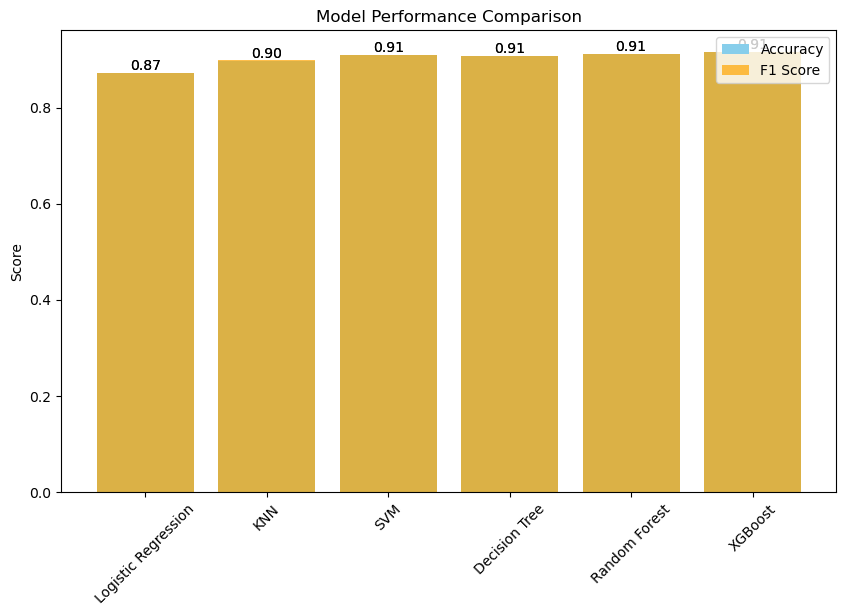

In [142]:
#Comparison of models

plt.figure(figsize=(10,6))
bars = plt.bar(results.keys(), [results[m]["accuracy"] for m in results], 
               color="skyblue", label="Accuracy")
bars2 = plt.bar(results.keys(), [results[m]["f1"] for m in results], 
                color="orange", alpha=0.7, label="F1 Score")

# Add value labels
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"{bar.get_height():.2f}", ha='center', va='bottom')
for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"{bar.get_height():.2f}", ha='center', va='bottom')

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend()
plt.show()


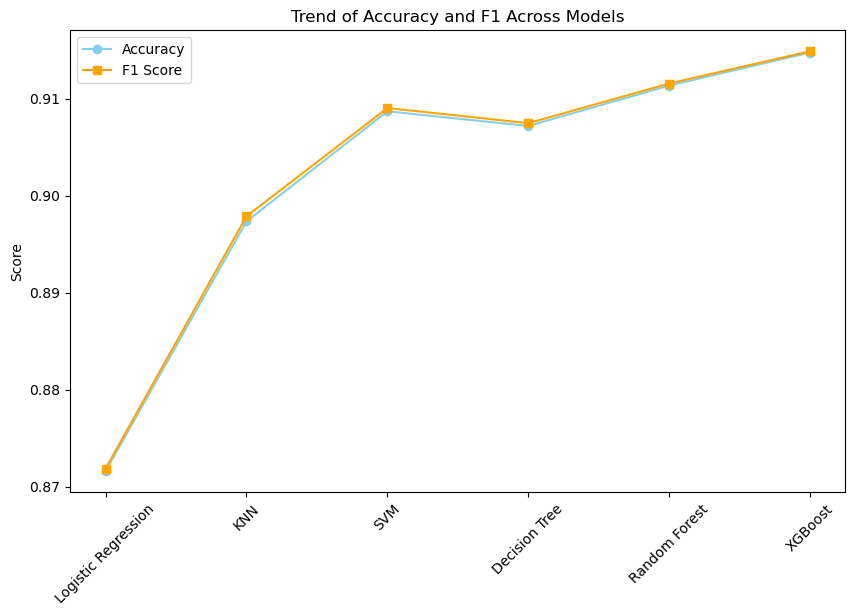

In [143]:
models_list = list(results.keys())
acc_scores = [results[m]["accuracy"] for m in models_list]
f1_scores = [results[m]["f1"] for m in models_list]
plt.figure(figsize=(10,6))
plt.plot(models_list, acc_scores, marker='o', label="Accuracy", color="skyblue")
plt.plot(models_list, f1_scores, marker='s', label="F1 Score", color="orange")

plt.title("Trend of Accuracy and F1 Across Models")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend()
plt.show()


In [144]:
#Selecting the best performed model

# Select best model by F1 score
best_model_name = max(results, key=lambda m: results[m]["f1"])
best_model = best_models[best_model_name]

print(f"\nBest Model: {best_model_name}")
print("Performance:", results[best_model_name])


Best Model: XGBoost
Performance: {'accuracy': 0.9147727272727273, 'f1': 0.914903375777237, 'best_params': {'classifier__learning_rate': 0.2, 'classifier__max_depth': 7, 'classifier__n_estimators': 200, 'classifier__subsample': 0.8}}


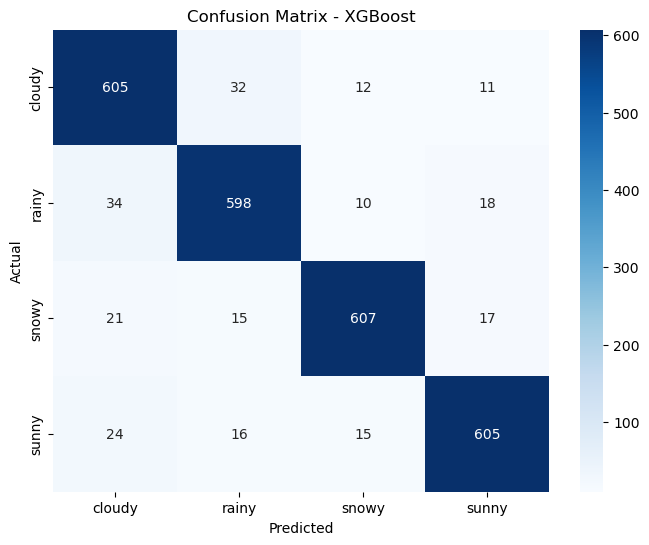

In [145]:
from sklearn.metrics import confusion_matrix

# Predict with best model
y_pred_best = best_model.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()